# ECMWF TC Tracks & Wind Pipeline

This notebook demonstrates the TC track and wind processing pipeline: from BUFR download through to ensemble wind threshold envelopes.

For precipitation, see `pipeline_demonstration_precipitation.ipynb`.

## Overview

| Step | Module | Output |
|---|---|---|
| 1. Download TC Data | `ecmwf_tc_data_downloader` | Single BUFR4 per run (all storms, all members) |
| 2. Extract BUFR | `ecmwf_tc_data_extractor` | Per-storm CSVs (one file per named storm) |
| 3. Transform | `ecmwf_tc_data_transformer` | Standardised tracks with wind radii + WKT polygons |
| 4. Download Wind | `ecmwf_wind_data_downloader` | Ensemble 10m wind GRIB files (`type="pf"/"cf"`) |
| 5. Wind Combination | `ecmwf_tc_wind_combination` | Wind threshold contours, unioned across forecast steps |

| Output file | Snowflake table | Contents |
|---|---|---|
| `*_transformed.csv` | `TC_TRACKS` | One row per member × step, with wind radii and polygons |
| `*_envelopes_individual.csv` | `TC_ENVELOPES_INDIVIDUAL` | Wind threshold polygon per member × step |
| `*_envelopes_combined.csv` | `TC_ENVELOPES_COMBINED` | Unioned wind polygon per member × threshold |

## Setup


In [8]:
import os
import pandas as pd
from pathlib import Path

# Pipeline modules
from ecmwf_tc_data_downloader import download_tc_data, list_downloaded_files
from ecmwf_tc_data_extractor import extract_tc_data, filter_tc_data, save_per_storm_csvs
from ecmwf_tc_data_transformer import transform_tc_data_from_file
from ecmwf_wind_data_downloader import download_ensemble_wind
from ecmwf_tc_wind_combination import process_wind_combination

In [9]:
# ── Date / run-time selection ──────────────────────────────────────────────
#
# ECMWF publishes four TC track forecast runs per day:
#   00Z  (published ~09:00 UTC)  →  240-hour track horizon
#   06Z  (published ~13:00 UTC)  →  144-hour track horizon
#   12Z  (published ~21:00 UTC)  →  240-hour track horizon
#   18Z  (published ~01:00 UTC)  →  144-hour track horizon
#
# Leave SELECTED_DATE empty ("") to download the most recent available run.

SELECTED_DATE    = ""           # "YYYYMMDD" or "" for latest
SELECTED_RUNTIME = ""         # "00" / "06" / "12" / "18", or "" for latest

if SELECTED_DATE:
    print(f"Target: {SELECTED_DATE} {SELECTED_RUNTIME or 'any'}Z")
else:
    print("Target: latest available forecast (determined by ecmwf-opendata client)")

Target: latest available forecast (determined by ecmwf-opendata client)


In [10]:
# Example override — uncomment and set to target a specific run:
# SELECTED_DATE    = "20251109"
# SELECTED_RUNTIME = "00"

In [11]:
# Create output directories
directories = {
    'tc_data':        'tc_data',          # downloaded BUFR files + extracted per-storm CSVs
    'tc_transformed': 'tc_transformed',   # transformed TC CSVs
    'wind_data':      'wind_data',        # wind GRIB files
    'wind_extracted': 'wind_extracted',   # wind envelope CSVs
}

for dir_path in directories.values():
    Path(dir_path).mkdir(exist_ok=True)

## Step 1: Download TC Data


In [12]:
# Download TC data — returns a single combined BUFR4 file per forecast run
# (all active storms × all 51 ensemble members in one file)
result = download_tc_data(
    date=SELECTED_DATE,
    run_time=SELECTED_RUNTIME,
    output_dir=directories['tc_data'],
)
print(f"Downloaded: {result['downloaded']}  Failed: {result['failed']}")

bufr_files = list(Path(directories['tc_data']).glob("*.bufr4"))
print(f"BUFR files: {[f.name for f in bufr_files]}")

2026-07-02 08:56:55,694 - INFO - Downloading TC tracks: 2026-07-01 18Z (step=144h)
2026-07-02 08:56:55,695 - INFO - Downloading https://data.ecmwf.int/forecasts/20260701/18z/ifs/0p25/enfo/20260701180000-144h-enfo-tf.bufr
2026-07-02 08:56:56,229 - INFO - Downloaded: tc_tracks_2026-07-01_r18.bufr4 (340 KB)
2026-07-02 08:56:56,229 - INFO - TC download complete — downloaded: 1, failed: 0


By downloading data from the ECMWF open data dataset, you agree to the terms: Attribution 4.0 International (CC BY 4.0). Please attribute ECMWF when downloading this data.
Downloaded: 1  Failed: 0
BUFR files: ['tc_tracks_2026-07-01_r18.bufr4', 'tc_tracks_2026-07-01_r00.bufr4']


## Step 2: Extract BUFR Data


In [13]:
# Extract all storms from the combined BUFR file,
# filter to named storms, and write one CSV per storm.
per_storm_csvs = []

for bufr_file in bufr_files:
    print(f"Extracting: {bufr_file.name}")
    df = extract_tc_data(str(bufr_file), verbose=False)

    if df.empty:
        print("  No data extracted")
        continue

    df = filter_tc_data(df, named_storms_only=True)
    if df.empty:
        print("  No named storms found")
        continue

    storms = df['storm_id'].unique()
    print(f"  Named storms: {list(storms)}")

    csv_paths = save_per_storm_csvs(df, directories['tc_data'], bufr_file.name, verbose=True)
    per_storm_csvs.extend(csv_paths)

print(f"\nPer-storm CSVs written: {len(per_storm_csvs)}")
for p in per_storm_csvs:
    print(f"  {p}")

Extracting: tc_tracks_2026-07-01_r18.bufr4
Number of Ensemble Members:  51
Number of Ensemble Members:  51
Number of Ensemble Members:  51
Number of Ensemble Members:  51
Number of Ensemble Members:  49
Number of Ensemble Members:  22
Number of Ensemble Members:  8
Number of Ensemble Members:  1
Number of Ensemble Members:  51
Number of Ensemble Members:  43
Number of Ensemble Members:  16
Number of Ensemble Members:  4
Number of Ensemble Members:  43
Number of Ensemble Members:  16
Number of Ensemble Members:  4
Number of Ensemble Members:  2
Number of Ensemble Members:  18
Number of Ensemble Members:  6
Number of Ensemble Members:  1
Number of Ensemble Members:  10
Number of Ensemble Members:  10
Number of Ensemble Members:  33
Number of Ensemble Members:  5
Number of Ensemble Members:  1
Number of Ensemble Members:  17
Number of Ensemble Members:  5
Number of Ensemble Members:  51
Number of Ensemble Members:  39
Number of Ensemble Members:  20
Number of Ensemble Members:  6
Number o

In [14]:
# ── Storm selection ────────────────────────────────────────────────────────
# Available storms were printed above. Set SELECTED_STORM to one of them,
# or leave empty ("") to use the first available storm.

SELECTED_STORM = "MAILA"     # e.g. "MAILA", "VAIANU", "INDUSA", or "" for first

# Resolve storm name and filter all downstream processing to that storm only
_available_storms = sorted({
    Path(p).name.split('_storm_')[1].split('_')[0]
    for p in per_storm_csvs
    if '_storm_' in Path(p).name
})

if not _available_storms:
    raise RuntimeError(
        "No storm CSVs found — the download likely failed (404 for an old date). "
        "Update SELECTED_DATE in the Setup cell to a date within the last ~30 days "
        "when an active named storm was present."
    )

_storm = SELECTED_STORM.strip().upper() if SELECTED_STORM.strip() else _available_storms[0]
if _storm not in _available_storms:
    print(f"WARNING: '{_storm}' not found in {_available_storms}, defaulting to '{_available_storms[0]}'")
    _storm = _available_storms[0]

# Filter per_storm_csvs so Steps 3–5 only run for the selected storm
per_storm_csvs = [p for p in per_storm_csvs if f'_storm_{_storm}_' in Path(p).name]

# Dedicated subdirectories for the selected storm (keeps Step 5 isolated)
_storm_tc_dir      = Path(directories['tc_transformed']) / _storm
_storm_env_dir     = Path(directories['wind_extracted'])  / _storm
_storm_tc_dir.mkdir(exist_ok=True)
_storm_env_dir.mkdir(exist_ok=True)

print(f"Selected storm : {_storm}")
print(f"CSV to process : {[Path(p).name for p in per_storm_csvs]}")
print(f"Transform dir  : {_storm_tc_dir}")
print(f"Envelope dir   : {_storm_env_dir}")

Selected storm : DOUGLAS
CSV to process : ['tc_tracks_2026-07-01_r18_storm_DOUGLAS_extracted.csv']
Transform dir  : tc_transformed/DOUGLAS
Envelope dir   : wind_extracted/DOUGLAS


## Step 3: Transform Data


In [15]:
# Transform the selected storm's CSV into Snowflake-ready format
# (standardised units, wind radii, WKT polygons)
transformation_results = []

for csv_path in per_storm_csvs:
    csv_file = Path(csv_path)
    result = transform_tc_data_from_file(
        filename=str(csv_file),
        output_dir=str(_storm_tc_dir),
        verbose=True,
    )
    if result['success']:
        transformation_results.append(result)
        print(f"  {result['records']} records → {Path(result['csv_file']).name}")
    else:
        print(f"  Failed: {csv_file.name}")

transformed_files = [Path(r['csv_file']) for r in transformation_results]
print(f"\nTransformed files: {[f.name for f in transformed_files]}")

Transforming tropical cyclone data from: tc_data/tc_tracks_2026-07-01_r18_storm_DOUGLAS_extracted.csv
Transforming: tc_data/tc_tracks_2026-07-01_r18_storm_DOUGLAS_extracted.csv
  Loaded 7356 rows
 Validation passed: 7356 rows, 15 columns
  Forecast issued at: 2026-07-01 18:00:00
  Found 613 unique forecast points
  Converting 3285 wind radii records to wide format
  Converted pressure from Pa to hPa
  Converted wind speed from m/s to knots
  Calculating radius of maximum winds
  Creating wind field polygons for 34 kt winds
  Creating wind field polygons for 50 kt winds
  Creating wind field polygons for 64 kt winds
  Converting polygons to WKT format
  Saved 613 forecast records to tc_transformed/DOUGLAS/tc_tracks_2026-07-01_r18_storm_DOUGLAS_extracted_transformed.csv

  Transformation Summary:
    Input rows:  7356
    Output rows: 613 (deduplication: 6743 rows removed)
    Storms: 1
    Ensemble members: 51
    Time steps: 20
    Date range: 2026-07-01 18:00:00 to 2026-07-06 12:00:00

## Step 4: Download Wind Data


In [16]:
# Download wind forecast data for the same run as the TC data.
# forecast_hours controls how many lead times to fetch (every 6h, 0→144h = full range).
# Reduce the list here to speed up the notebook demo, e.g. list(range(0, 25, 6)).
forecast_hours = list(range(0, 145, 6))  # full range: 0, 6, 12, … 144h

if SELECTED_DATE:
    wind_date     = f"{SELECTED_DATE[:4]}-{SELECTED_DATE[4:6]}-{SELECTED_DATE[6:]}"
    wind_run_time = int(SELECTED_RUNTIME)
else:
    # If using latest TC data, derive date/run from the downloaded BUFR filename
    import re
    bufr_name  = bufr_files[0].stem          # e.g. "tc_tracks_2026-04-06_r06"
    wind_date  = re.search(r'(\d{4}-\d{2}-\d{2})', bufr_name).group(1)
    wind_run_time = int(re.search(r'_r(\d{2})', bufr_name).group(1))
    print(f"Derived from filename: date={wind_date}  run={wind_run_time:02d}Z")

wind_files = download_ensemble_wind(
    date=wind_date,
    run_time=wind_run_time,
    forecast_hours=forecast_hours,
    output_dir=directories['wind_data'],
)

Derived from filename: date=2026-07-01  run=18Z
ECMWF ENSEMBLE WIND FORECAST DOWNLOAD (CONCURRENT)
Date: 2026-07-01
Run: 18Z
Forecast hours: 25 steps (0-144h)
Concurrent workers: 4
Output: wind_data/
  [DOWN] +  0h PF: Downloading...  [DOWN] +  0h CF: Downloading...  [DOWN] +  6h PF: Downloading...  [DOWN] +  6h CF: Downloading...

2026-07-02 08:56:59,135 - INFO - Downloading https://data.ecmwf.int/forecasts/20260701/18z/ifs/0p25/oper/20260701180000-0h-oper-fc.grib2
20260701180000-0h-oper-fc.grib2:   0%|          | 0.00/1.65M [00:00<?, ?B/s]2026-07-02 08:56:59,160 - INFO - Downloading https://data.ecmwf.int/forecasts/20260701/18z/ifs/0p25/oper/20260701180000-6h-oper-fc.grib2
20260701180000-0h-oper-fc.grib2:  66%|██████▋   | 1.09M/1.65M [00:00<00:00, 5.91MB/s]2026-07-02 08:56:59,378 - INFO - Downloading https://data.ecmwf.int/forecasts/20260701/18z/ifs/0p25/enfo/20260701180000-6h-enfo-ef.grib2

                                                                                     

 (1.6 MB)
  [DOWN] + 12h PF: Downloading...

 (1.6 MB)
  [DOWN] + 12h CF: Downloading...


2026-07-02 08:56:59,559 - INFO - Downloading https://data.ecmwf.int/forecasts/20260701/18z/ifs/0p25/enfo/20260701180000-0h-enfo-ef.grib2
20260701180000-0h-enfo-ef.grib2:   0%|          | 0.00/84.2M [00:00<?, ?B/s]
20260701180000-0h-enfo-ef.grib2:   0%|          | 430k/84.2M [00:00<00:21, 4.17MB/s]2026-07-02 08:56:59,715 - INFO - Downloading https://data.ecmwf.int/forecasts/20260701/18z/ifs/0p25/oper/20260701180000-12h-oper-fc.grib2

20260701180000-0h-enfo-ef.grib2:   2%|▏         | 2.01M/84.2M [00:00<00:12, 6.85MB/s]
20260701180000-0h-enfo-ef.grib2:   3%|▎         | 2.77M/84.2M [00:00<00:12, 7.11MB/s]
20260701180000-0h-enfo-ef.grib2:   4%|▍         | 3.63M/84.2M [00:00<00:11, 7.68MB/s]


...

20260701180000-144h-enfo-ef.grib2:   8%|▊         | 6.17M/75.2M [00:01<00:11, 6.52MB/s]
20260701180000-144h-enfo-ef.grib2:   9%|▉         | 6.88M/75.2M [00:01<00:11, 6.05MB/s]


20260701180000-144h-enfo-ef.grib2:  10%|█         | 7.75M/75.2M [00:01<00:10, 6.76MB/s]


20260701180000-144h-enfo-ef.grib2:  11%|█▏        | 8.61M/75.2M [00:01<00:09, 7.25MB/s]


20260701180000-144h-enfo-ef.grib2:  12%|█▏        | 9.36M/75.2M [00:01<00:10, 6.87MB/s]


20260701180000-144h-enfo-ef.grib2:  14%|█▎        | 10.2M/75.2M [00:01<00:11, 6.07MB/s]


20260701180000-144h-enfo-ef.grib2:  15%|█▍        | 11.2M/75.2M [00:01<00:09, 6.92MB/s]


20260701180000-144h-enfo-ef.grib2:  16%|█▋        | 12.3M/75.2M [00:01<00:08, 7.60MB/s]





20260701180000-144h-enfo-ef.grib2:  17%|█▋        | 13.0M/75.2M [00:02<00:13, 4.78MB/s]


20260701180000-144h-enfo-ef.grib2:  19%|█▊        | 14.1M/75.2M [00:02<00:11, 5.72MB/s]

20260701180000-144h-enfo-ef.grib2:  20%|██        | 15.3M/75.2M [00:02<00:08, 7.20MB/s]

 (75.3 MB)




20260701180000-144h-enfo-ef.grib2:  23%|██▎       | 17.5M/75.2M [00:02<00:07, 8.43MB/s]

 (75.0 MB)


 (75.2 MB)
DOWNLOAD SUMMARY
Successfully downloaded: 50 files
Failed downloads: 0 files
Files saved to: wind_data/


## Step 5: Process Wind Combination


In [17]:
# Create wind threshold envelopes for the selected storm only
combination_result = process_wind_combination(
    tc_data_dir=_storm_tc_dir,
    wind_data_dir=Path(directories['wind_data']),
    output_dir=_storm_env_dir,
)

2026-07-02 08:58:12,020 - INFO - ======================================================================
2026-07-02 08:58:12,021 - INFO - ECMWF TC WIND COMBINATION PROCESSING (Sequential)
2026-07-02 08:58:12,021 - INFO - ======================================================================
2026-07-02 08:58:12,022 - INFO - Found TC data: DOUGLAS -> tc_tracks_2026-07-01_r18_storm_DOUGLAS_extracted_transformed.csv
2026-07-02 08:58:12,024 - INFO - Found 50 wind GRIB files:
2026-07-02 08:58:12,024 - INFO -   - wind_ens_2026-07-01_r18_f036h_pf.grib2
2026-07-02 08:58:12,025 - INFO -   - wind_ens_2026-07-01_r18_f000h_cf.grib2
2026-07-02 08:58:12,025 - INFO -   - wind_ens_2026-07-01_r18_f042h_cf.grib2
2026-07-02 08:58:12,025 - INFO -   - wind_ens_2026-07-01_r18_f132h_pf.grib2
2026-07-02 08:58:12,025 - INFO -   - wind_ens_2026-07-01_r18_f060h_pf.grib2
2026-07-02 08:58:12,026 - INFO -   - wind_ens_2026-07-01_r18_f126h_pf.grib2
2026-07-02 08:58:12,026 - INFO -   - wind_ens_2026-07-01_r18_f012h_cf.

## Results

In [18]:
from visualization import show_tracks, show_tracks_with_polygons, show_individual_envelopes, show_combined_envelopes

envelope_files = list(_storm_env_dir.glob("*.csv"))

print(f"Storm: {_storm}")
print(f"TC Track Data:  {len(transformed_files)} file(s)")
print(f"Wind Envelopes: {len(envelope_files)} file(s)")
for f in transformed_files:
    print(f"  - {f.name}")
for f in envelope_files:
    print(f"  - {f.name}")

# Pick the correct files for this storm
storm_transformed_file = transformed_files[0] if transformed_files else None
storm_individual_file  = next((f for f in envelope_files if 'individual' in f.name), None)
storm_combined_file    = next((f for f in envelope_files if 'combined'   in f.name), None)

print(f"\nTracks file:     {storm_transformed_file.name if storm_transformed_file else 'NOT FOUND'}")
print(f"Individual file: {storm_individual_file.name  if storm_individual_file  else 'NOT FOUND'}")
print(f"Combined file:   {storm_combined_file.name    if storm_combined_file    else 'NOT FOUND'}")

Storm: DOUGLAS
TC Track Data:  1 file(s)
Wind Envelopes: 2 file(s)
  - tc_tracks_2026-07-01_r18_storm_DOUGLAS_extracted_transformed.csv
  - DOUGLAS_20260701T18Z_envelopes_individual.csv
  - DOUGLAS_20260701T18Z_envelopes_combined.csv

Tracks file:     tc_tracks_2026-07-01_r18_storm_DOUGLAS_extracted_transformed.csv
Individual file: DOUGLAS_20260701T18Z_envelopes_individual.csv
Combined file:   DOUGLAS_20260701T18Z_envelopes_combined.csv


TC TRACK VISUALIZATION
Loaded 613 track points from tc_tracks_2026-07-01_r18_storm_DOUGLAS_extracted_transformed.csv
Storm: DOUGLAS
Forecast: 2026-07-01 18:00:00
Ensemble members: 51


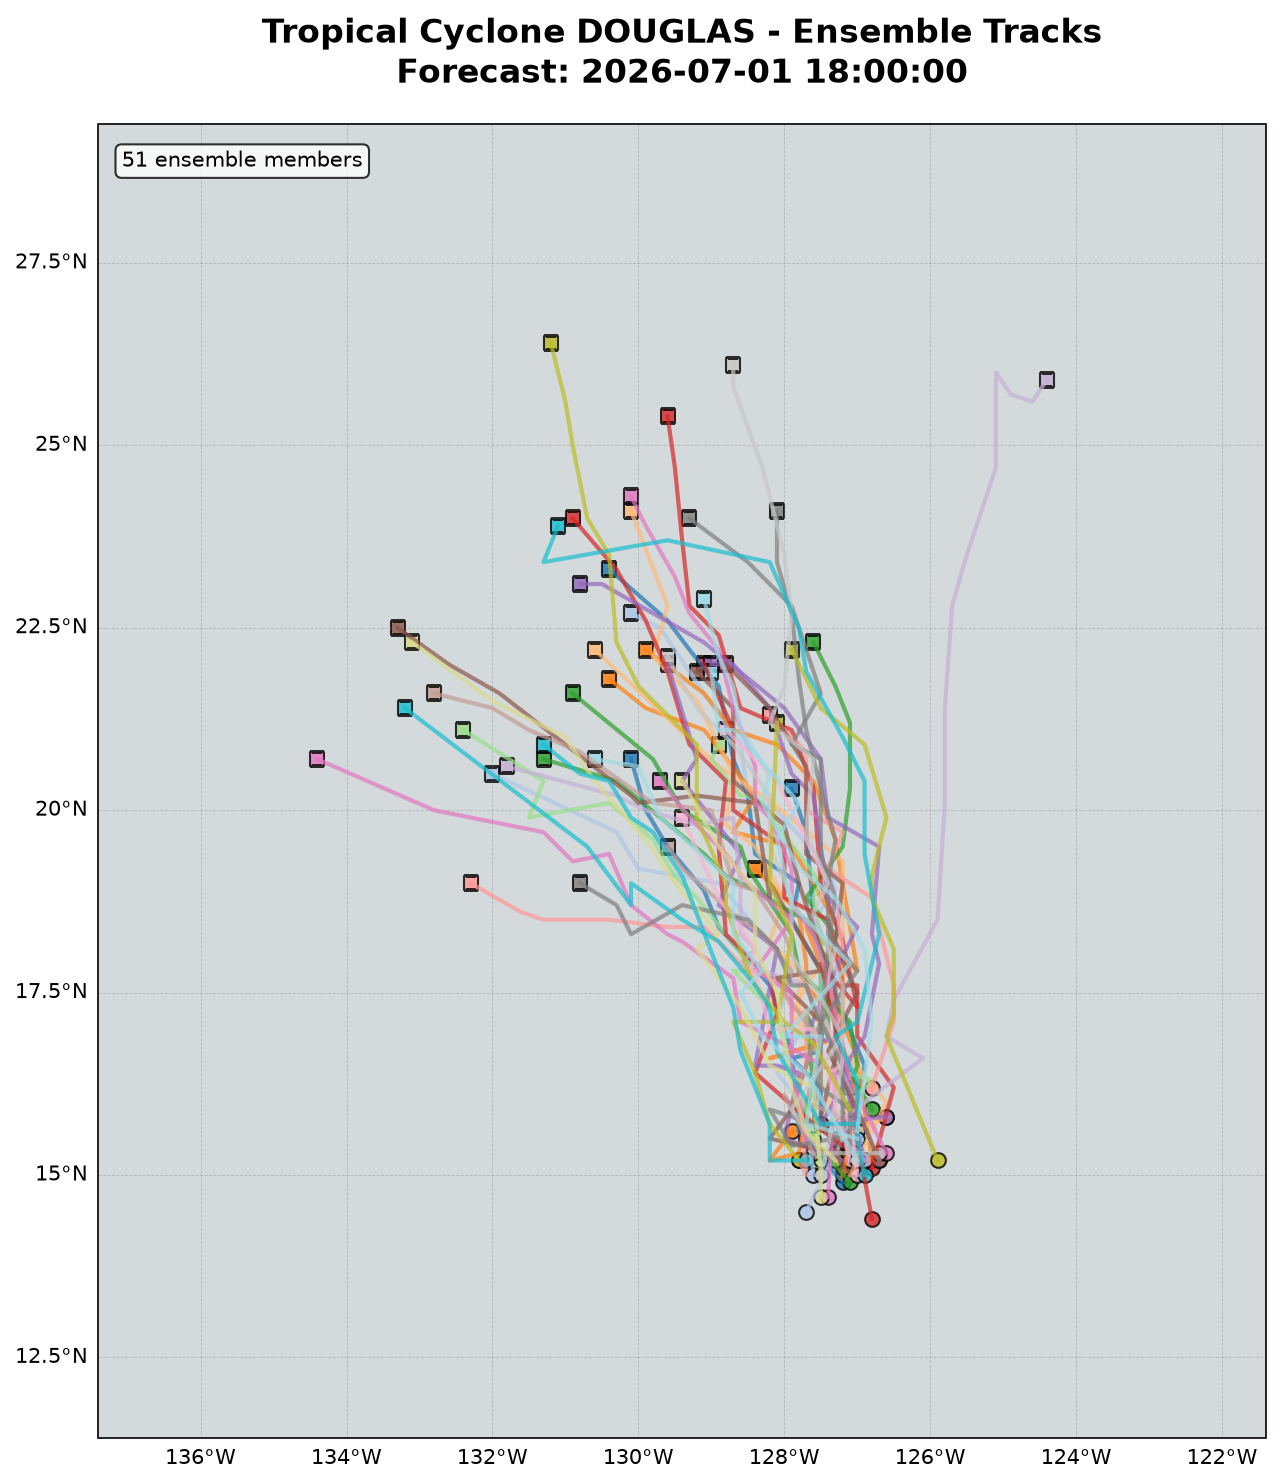

In [19]:
# TC track visualization for the selected storm
show_tracks(str(storm_transformed_file))

TC TRACKS WITH WIND POLYGONS
Loaded 613 track points from tc_tracks_2026-07-01_r18_storm_DOUGLAS_extracted_transformed.csv
Storm: DOUGLAS
Forecast: 2026-07-01 18:00:00
Showing 3 members
Wind polygon columns: ['wind_field_polygon_34kt', 'wind_field_polygon_50kt', 'wind_field_polygon_64kt']
Available wind thresholds: [34, 50, 64]


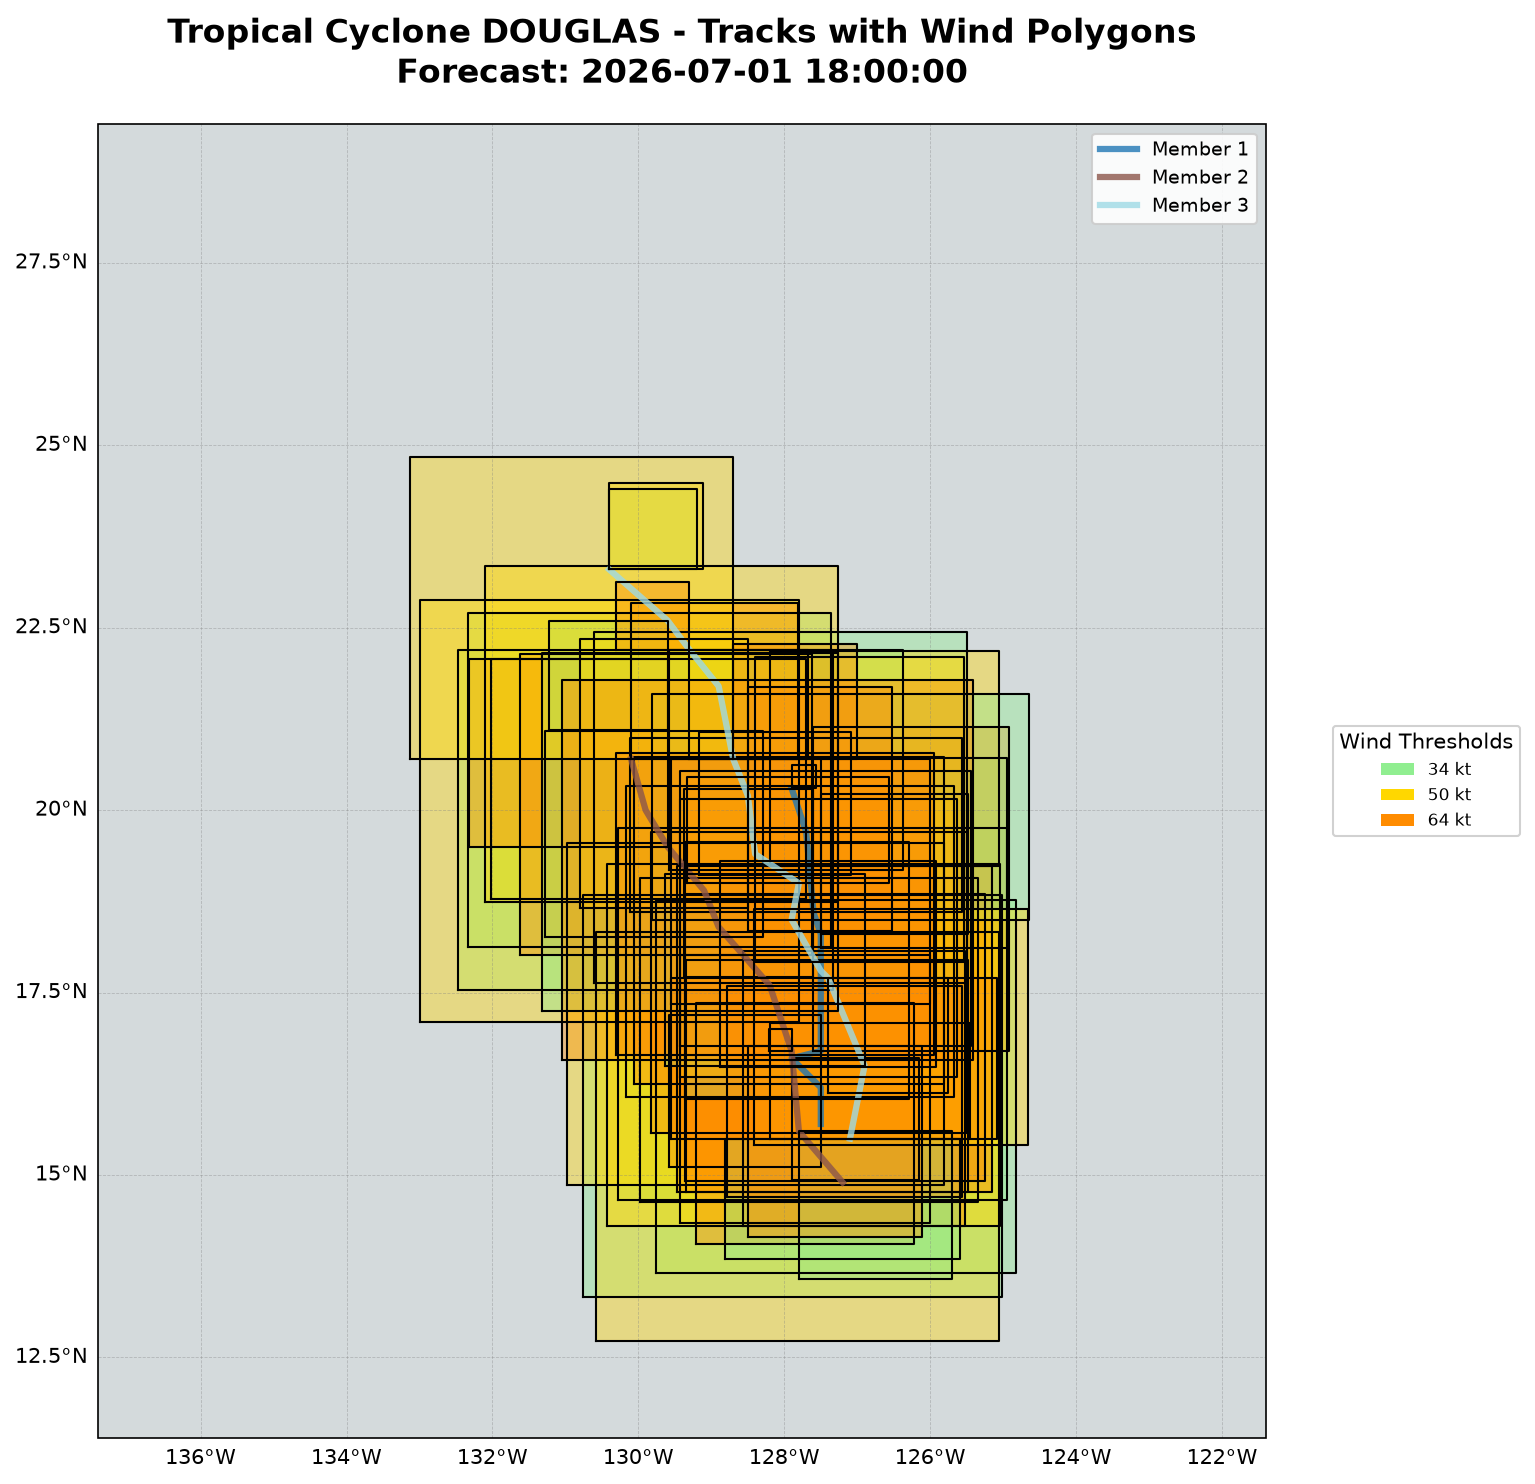

In [20]:
# TC tracks with wind field polygons for the selected storm
show_tracks_with_polygons(str(storm_transformed_file))

INDIVIDUAL WIND ENVELOPES
Loaded 263 records from DOUGLAS_20260701T18Z_envelopes_individual.csv
Found 263 records with polygons
Storm: DOUGLAS
Forecast: 2026-07-01 18:00:00
Member: 1
Forecast steps: 3


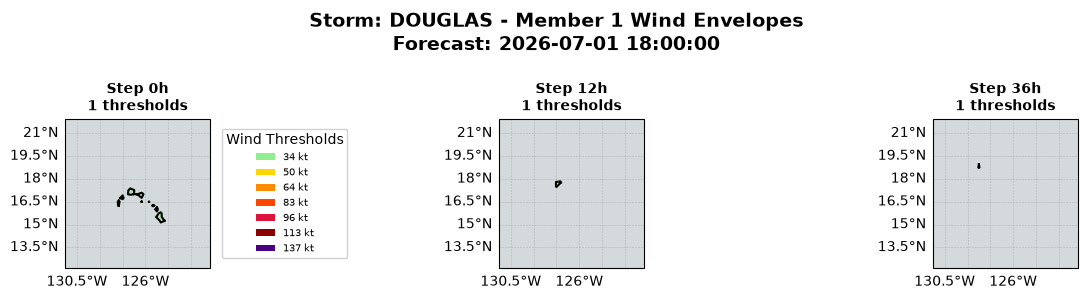

In [21]:
# Individual wind envelopes for the selected storm
show_individual_envelopes(str(storm_individual_file))

COMBINED WIND ENVELOPES
Loaded 76 records from DOUGLAS_20260701T18Z_envelopes_combined.csv
Found 76 records with polygons
Storm: DOUGLAS
Forecast: 2026-07-01 18:00:00
Showing 3 members


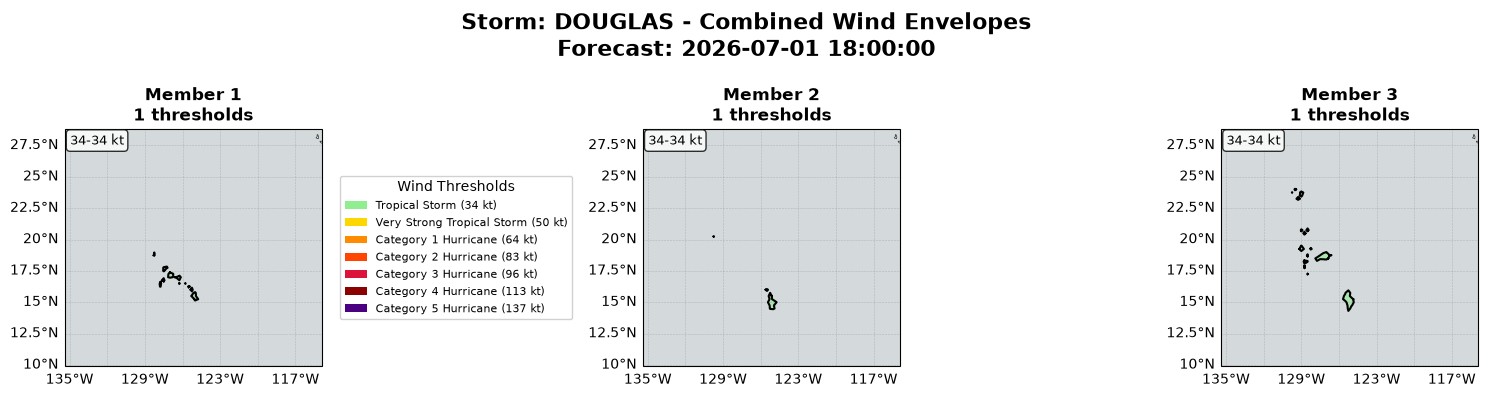

In [22]:
# Combined wind envelopes for the selected storm
show_combined_envelopes(str(storm_combined_file))